#LGBM & XGBM

##Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

##Loading the data set

In [ ]:
df = pd.read_csv("/content/diabetes (2).csv")

In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


#EDA
## Missing Values

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


##Histogram

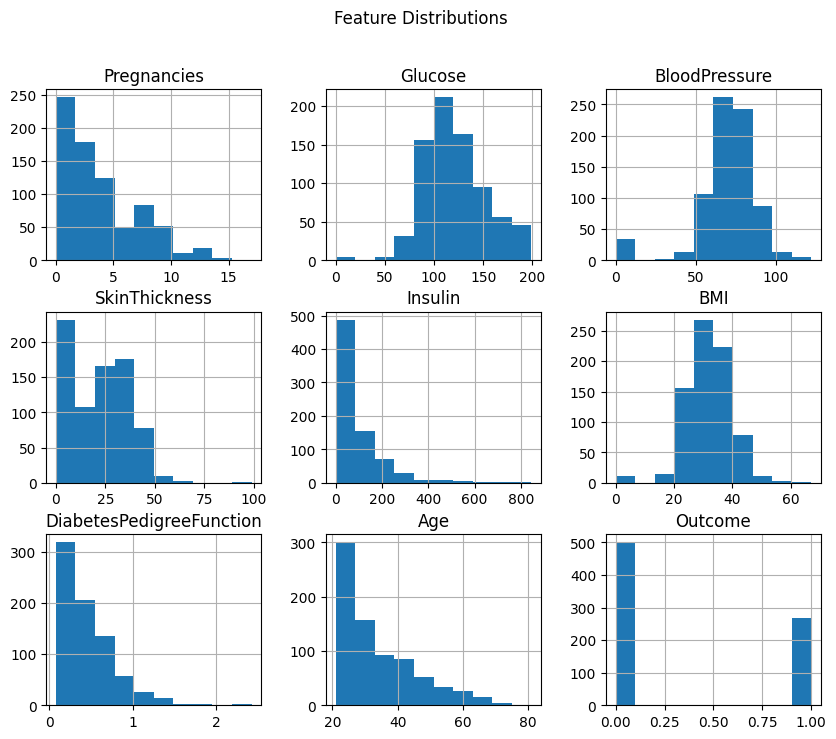

In [ ]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

##BoxPlot

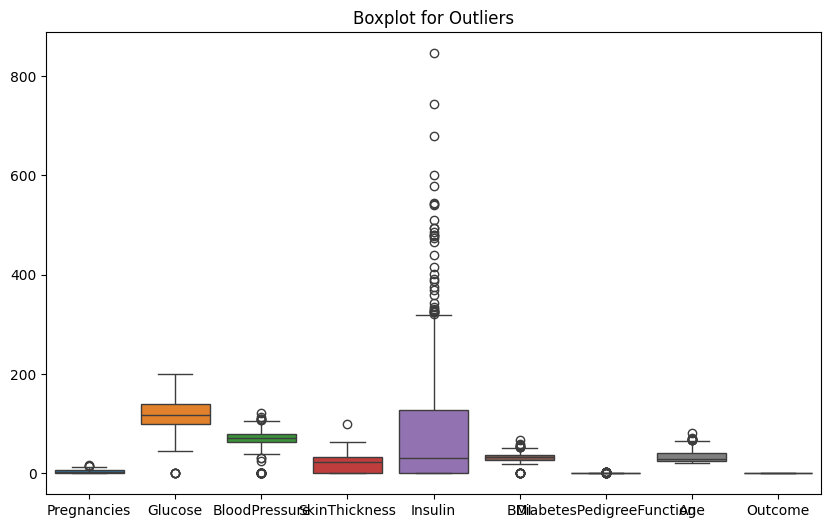

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outliers")
plt.show()

#Scatter plots

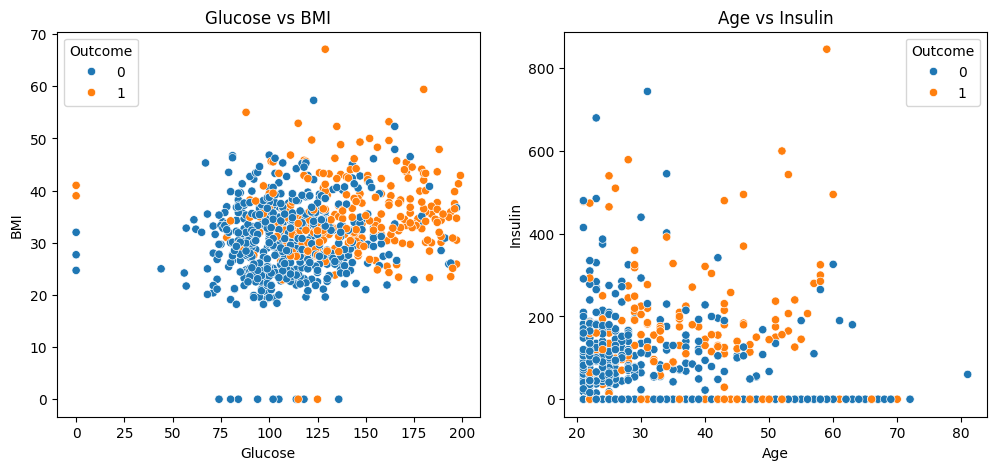

In [ ]:
# Scatter plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("Glucose vs BMI")

plt.subplot(1,2,2)
sns.scatterplot(x='Age', y='Insulin', hue='Outcome', data=df)
plt.title("Age vs Insulin")

plt.show()


#####Patients with higher glucose and BMI levels are more likely to have diabetes.
#####There is some overlap between classes, indicating that classification is not perfectly separable.


#Bar Plot

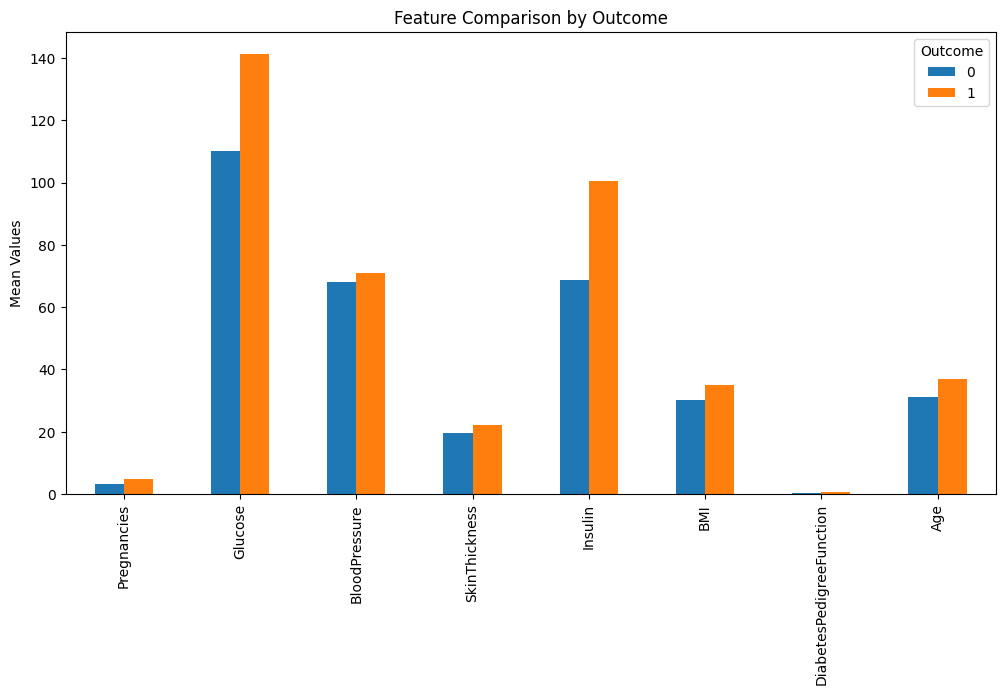

In [ ]:
# Bar plot (mean comparison)
df.groupby('Outcome').mean().T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Comparison by Outcome")
plt.ylabel("Mean Values")
plt.show()

#####Features like Glucose, BMI, and Age have higher average values for diabetic patients.
#####These features are strong indicators for predicting diabetes.


##Correlation Heatmap

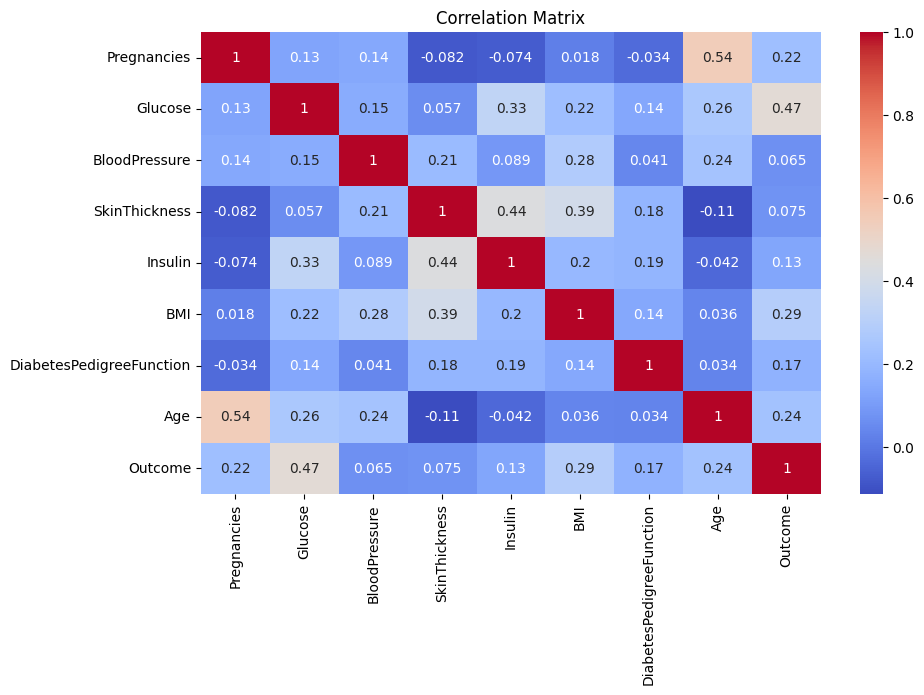

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##Outcome distribution

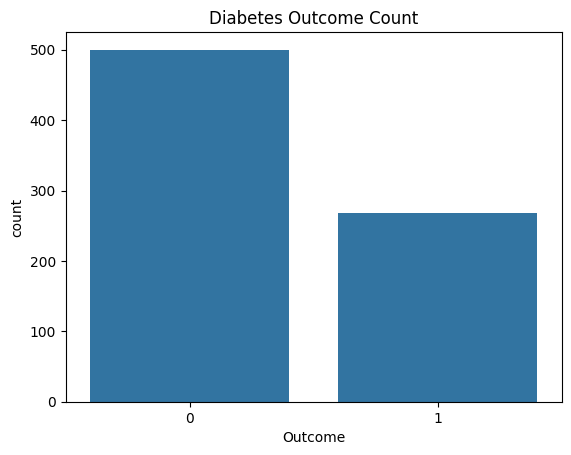

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Count")
plt.show()

#Data Preprocessing


In [ ]:
#Replace 0 values (invalid in some columns) with median
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

#Split data

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Model 1: XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))


XGBoost Results
Accuracy: 0.7207792207792207
Precision: 0.6
Recall: 0.6545454545454545
F1 Score: 0.6260869565217392


#Model 2: LightGBM

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgb = LGBMClassifier()

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)

print("\nLightGBM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1 Score:", f1_score(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

#Cross Validation

In [ ]:
xgb_cv = cross_val_score(xgb, X, y, cv=5)
lgb_cv = cross_val_score(lgb, X, y, cv=5)

print("\nXGBoost CV Accuracy:", xgb_cv.mean())
print("LightGBM CV Accuracy:", lgb_cv.mean())


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

#Model Comparision Visualisation

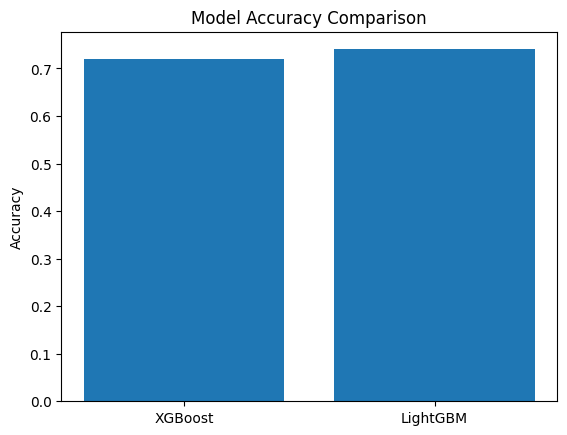

In [ ]:
models = ['XGBoost', 'LightGBM']
accuracy = [
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


#Confusion Matrix

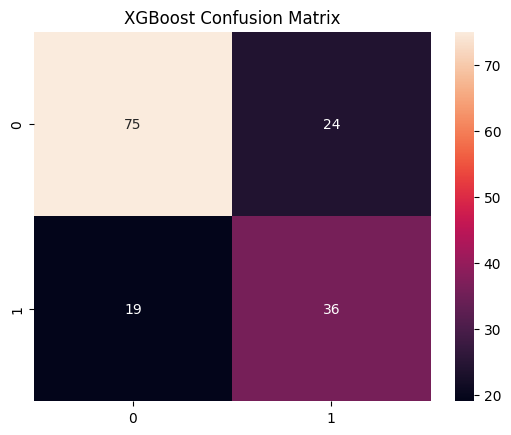

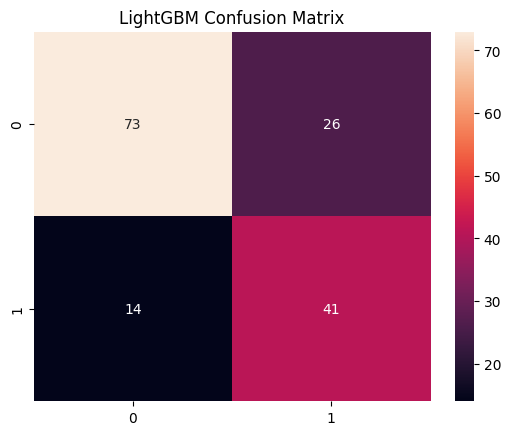

In [ ]:
from sklearn.metrics import confusion_matrix

# XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

# LightGBM
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d')
plt.title("LightGBM Confusion Matrix")
plt.show()


#Feature Importance

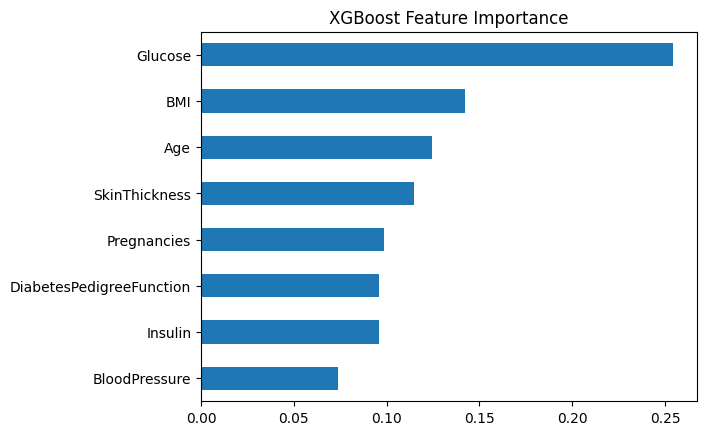

In [ ]:
import pandas as pd

importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()


#Hyper Parameters Tuning

In [ ]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), params, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters (XGBoost):", grid.best_params_)


Best Parameters (XGBoost): {'max_depth': 3, 'n_estimators': 100}


#Conclusion
#####XGBoost and LightGBM models were successfully implemented for diabetes prediction.
#####EDA and visualization helped understand feature relationships.
#####XGBoost achieved slightly better performance compared to LightGBM.
#####Cross-validation confirmed model stability.
#####Overall, boosting techniques provide strong predictive performance for this dataset.
